- 知识点：
    - 宏观上知道一个智能模型从无到有：
        - 实现模型：
        - 数据集处理：
        - 训练模型：
        - 模型推理

# 1. LetNet网络

- 模块(Module)：
    - 层(Layer)
        - 运算层
            - 全连接运算-线性运算（分类器）
            - 卷积运算（图像特征抽取器）
        - 激活层
            - 修正线性单元
                - relu
                - ...
            - 池化层
                - 最值池化

In [ ]:
import torch
class Lenet5(torch.nn.Module):
    def __init__(self):
        super(Lenet5, self).__init__()
        # 1. 定义5*5卷积层 1->6  5 * 5   padding=2   （28 * 28 -> 28 * 28)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        #     |- 池化层：抛弃不重要特征，降维（提升运算量）maxpool
        self.conv1 = torch.nn.Conv2d(
            in_channels=1,   # 输入图像的通道
            out_channels=6,  # 输出特征图的个数（通道）
            kernel_size=5,   # 卷积核大小
            # stride=1,        # 卷积核华东的步长step = stride
            padding=2,       # 补边
            # bias=True,       # 偏差 Y=WX+ b其中的b
        )
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2) # 2或者(2, 2)
        
        # 2. 定义5 * 5卷积 6->16 5 * 5， pandding=0(不补边) (14 * 14 -> 10 * 10)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        #     |- 池化层：抛弃不重要特征，降维（提升运算量）maxpool
        self.conv2 = torch.nn.Conv2d(6, 16, 5)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)
        
        # 3. 定义5 * 5卷积16 -> 120  5 * 5, padding=0 (5 * 5 -> 1 * 1)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        self.conv3 = torch.nn.Conv2d(16, 120, 5)
        self.relu3 = torch.nn.ReLU()
        
        # 把120 * 1 *1 变成120长的向量
        
        # 4. 定义线性运算  120 -> 84
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        self.fc4 = torch.nn.Linear(120, 84)
        self.relu4 = torch.nn.ReLU()

        # 5. 定义线性运算 84 -> 10
        self.fc5 = torch.nn.Linear(84, 10)
        # 推理判断        
        

    def forward(self, x):
        # 实现运算
        x = self.conv1(x)    # 可调用对象
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)

        # x = torch.flatten(x)   # 把120 * 1 * 1的数组变成(1, 120)的向量(注意：批次不要被吃掉)
        x = x.view(1, 120)   # （N, ...）

        x = self.fc4(x)
        x = self.relu4(x)

        x = self.fc5(x)
        return x

    

# 2. 模拟实现推理

In [ ]:
# 生成模拟数据（N，C，H， W）：批次数量， 通道，高度， 宽度 （1, 1, 28, 28）：随机
x = torch.randn(1, 1, 28, 28)
# 生成网络结构
model = Lenet5()
print(model)
# 推理
y = model(x)
print(y)
# 处理推理数据
p, c = torch.max(y, dim=1)   # 
print(v, p)
print(F"类别是：{c.detach().item()},概率是:{p.detach().item()}")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
tokenizer = AutoTokenizer.from_pretrained(
    r"D:\DeepSeek\DeepSeek-Coder-V2-Lite-Instruct", 
    trust_remote_code=True
)
model = AutoModelForCausalLM.from_pretrained(
    r"D:\DeepSeek\DeepSeek-Coder-V2-Lite-Instruct", 
    trust_remote_code=True, 
    torch_dtype=torch.bfloat16     # 混合精度：量化
).cuda()

input_text = "使用C++写一个冒泡算法"
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

outputs = model.generate(**inputs, max_length=128)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

In [ ]:
model

# 3. 数据集加载

- 数据集的来源：
    - 各种框架中处理好的数据，直接使用。
        - scikit-learning机器学习的数据
        - torch中封装的数据集
    - 来自开源数据集
        - HuggingFace
        - ModelScope
        - github（小数据集）
    - 用户采集
        - 采集
        - 标注
        - 格式转换

```python
torchvision.datasets.MNIST(
    root: Union[str, Path],    # 目录
    train: bool = True,        # 训练或者验证集
    transform: Optional[Callable] = None,  # 加载的图像默认是PIL.Image（转换为张量）
    target_transform: Optional[Callable] = None,   # 标签的处理
    download: bool = False)  #是否在在（没有一定下载）
```

In [6]:
import torch
import torchvision

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)

ds_train = torchvision.datasets.MNIST(
    root="./mnist",
    train=True,
    transform=transform,
    download=True
)

In [7]:
len(ds_train)

60000

In [8]:
ds_valid = torchvision.datasets.MNIST(
    root="./mnist",
    train=False,
    transform=transform,
    download=True
)

In [9]:
len(ds_valid)

10000

In [12]:
ds_train[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [13]:
ds_train[0][1]

5

In [14]:
ds_train[0][0].shape

torch.Size([1, 28, 28])

(28, 28, 1)


True

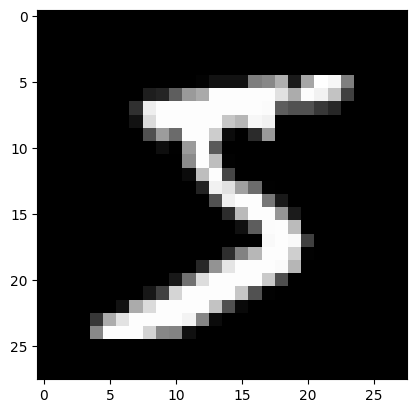

In [24]:
# 怎么把张量图像，转换为数组，使用matplotlib显示（h， w, c）
import numpy
x = ds_train[0][0]
x = x.permute(1, 2, 0)
# 转换为数组
x = x.numpy()
# 值转换为0-255（0-1）
x = x * 255
x = x.astype(numpy.uint8)
print(x.shape)
import matplotlib.pyplot as plt
plt.imshow(x, cmap="grey")

import cv2
cv2.imwrite("5.jpg", x)

In [27]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy
import cv2

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)

ds_train = torchvision.datasets.MNIST(
    root="./mnist",
    train=True,
    transform=transform,
    download=True
)
ds_valid = torchvision.datasets.MNIST(
    root="./mnist",
    train=False,
    transform=transform,
    download=True
)

def save_pic(ds, idx):
    x = ds[idx][0]    # 重点了解数据集的内部格式。[(img1, label1), (img2, label2), ...]
    y = ds[idx][1]
    x = x.permute(1, 2, 0)
    # 转换为数组
    x = x.numpy()
    # 值转换为0-255（0-1）
    x = x * 255
    x = x.astype(numpy.uint8)
    cv2.imwrite(F"pic_{idx:05d}_{y}.jpg", x)

save_pic(ds_train, 0)
save_pic(ds_train, 4)
save_pic(ds_train, 1000)

- 数据集不可能一个一个样本训练
- 批次数据集（数据集转换为批次数据集：生成器）
    - 数据集一个加载
    - 批次数据集加载多个

```python
torch.utils.data.DataLoader(
    dataset,          # 数据集
    batch_size=1,     # 批次数量（根据电脑硬件GPU大小，CPU内存大小）
    shuffle=None,     # 随机打乱
    num_workers=0,    # 使用多进程
    collate_fn=None,  # 数据调整器（处理数据，并是的所有的批次数据大小一样，才能构成矩阵）
```

In [28]:
loader_train = torch.utils.data.DataLoader(
    dataset=ds_train,
    batch_size=1000,
    shuffle=True
)
loader_valid = torch.utils.data.DataLoader(
    dataset=ds_valid,
    batch_size=1000,
    shuffle=False
)

In [31]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy
import cv2
# ---------------------------------1. 定义模型--------------------------------------------
class Lenet5(torch.nn.Module):
    def __init__(self):
        super(Lenet5, self).__init__()
        # 1. 定义5*5卷积层 1->6  5 * 5   padding=2   （28 * 28 -> 28 * 28)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        #     |- 池化层：抛弃不重要特征，降维（提升运算量）maxpool
        self.conv1 = torch.nn.Conv2d(
            in_channels=1,   # 输入图像的通道
            out_channels=6,  # 输出特征图的个数（通道）
            kernel_size=5,   # 卷积核大小
            # stride=1,        # 卷积核华东的步长step = stride
            padding=2,       # 补边
            # bias=True,       # 偏差 Y=WX+ b其中的b
        )
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2) # 2或者(2, 2)
        
        # 2. 定义5 * 5卷积 6->16 5 * 5， pandding=0(不补边) (14 * 14 -> 10 * 10)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        #     |- 池化层：抛弃不重要特征，降维（提升运算量）maxpool
        self.conv2 = torch.nn.Conv2d(6, 16, 5)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)
        
        # 3. 定义5 * 5卷积16 -> 120  5 * 5, padding=0 (5 * 5 -> 1 * 1)
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        self.conv3 = torch.nn.Conv2d(16, 120, 5)
        self.relu3 = torch.nn.ReLU()
        
        # 把120 * 1 *1 变成120长的向量
        
        # 4. 定义线性运算  120 -> 84
        #     |- 激活层 relu（负数变0：钝化，正数才有效果。）
        self.fc4 = torch.nn.Linear(120, 84)
        self.relu4 = torch.nn.ReLU()

        # 5. 定义线性运算 84 -> 10
        self.fc5 = torch.nn.Linear(84, 10)
        # 推理判断        
        

    def forward(self, x):
        # 实现运算
        x = self.conv1(x)    # 可调用对象
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)

        # x = torch.flatten(x)   # 把120 * 1 * 1的数组变成(1, 120)的向量(注意：批次不要被吃掉)
        x = x.view(-1, 120)   # （N, ...）

        x = self.fc4(x)
        x = self.relu4(x)

        x = self.fc5(x)
        return x
model = Lenet5()

# ---------------------------------2. 加载数据集与批次数据集--------------------------------------------
transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),]
)

ds_train = torchvision.datasets.MNIST(root="./mnist", train=True, transform=transform, download=True)
ds_valid = torchvision.datasets.MNIST(root="./mnist", train=False, transform=transform, download=True)

loader_train = torch.utils.data.DataLoader(dataset=ds_train, batch_size=1000, shuffle=True)
loader_valid = torch.utils.data.DataLoader(dataset=ds_valid, batch_size=1000, shuffle=False)

# ---------------------------------3. 训练--------------------------------------------
for x, y in loader_valid:
    # print(x.shape)   
    # print(y.shape)
    # 前向预测
    y_ = model(x)
    # y_, y计算损失度
    # 反向求导

    # 使用优化器更新梯度
    print(y_.shape)
    break
    # ---------------------------------4. 推理验证--------------------------------------------

torch.Size([1000, 10])


# 4. 模型训练

# 5. 比较训练前后的差别